In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1 - Thống kê mô tả và đặc trưng

## 1.1

In [2]:
df = sns.load_dataset('iris')
print('5 dòng đầu của dữ liệu là:')
print(df.head())
print(f'Số dòng và số cột: {df.shape}')
print('Kiểu dữ liệu cho từng cột là:')
print(df.dtypes)

5 dòng đầu của dữ liệu là:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Số dòng và số cột: (150, 5)
Kiểu dữ liệu cho từng cột là:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## 1.2


In [3]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
for feature in features:
    print(f'Feature: {feature}')
    print(f'Mean: {df[feature].mean()}')
    print(f'Median: {df[feature].median()}')
    print(f'Mode: {df[feature].mode()}')
    print(f'Var: {df[feature].var()}')
    print(f'Std: {df[feature].std()}')
    print(f'Min: {df[feature].min()}')
    print(f'Max: {df[feature].max()}')
    print(f'Q1: {df[feature].quantile(0.25)}')
    print(f'Q3: {df[feature].quantile(0.75)}')
    print(f"IQR: {df[feature].quantile(0.75) - df[feature].quantile(0.25)}")

Feature: sepal_length
Mean: 5.843333333333334
Median: 5.8
Mode: 0    5.0
Name: sepal_length, dtype: float64
Var: 0.6856935123042507
Std: 0.828066127977863
Min: 4.3
Max: 7.9
Q1: 5.1
Q3: 6.4
IQR: 1.3000000000000007
Feature: sepal_width
Mean: 3.0573333333333337
Median: 3.0
Mode: 0    3.0
Name: sepal_width, dtype: float64
Var: 0.189979418344519
Std: 0.4358662849366982
Min: 2.0
Max: 4.4
Q1: 2.8
Q3: 3.3
IQR: 0.5
Feature: petal_length
Mean: 3.7580000000000005
Median: 4.35
Mode: 0    1.4
1    1.5
Name: petal_length, dtype: float64
Var: 3.116277852348993
Std: 1.7652982332594662
Min: 1.0
Max: 6.9
Q1: 1.6
Q3: 5.1
IQR: 3.4999999999999996
Feature: petal_width
Mean: 1.1993333333333336
Median: 1.3
Mode: 0    0.2
Name: petal_width, dtype: float64
Var: 0.5810062639821029
Std: 0.7622376689603465
Min: 0.1
Max: 2.5
Q1: 0.3
Q3: 1.8
IQR: 1.5


## 1.3

In [4]:
df_grouped = df.groupby('species').agg(['mean', 'std'])
print(df_grouped)

           sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650  


### Nhận xét:
Loài setosa có sự khác biệt rõ ràng nhất, cụ thể:
- sepal_width_mean lớn hơn (~0.65 và ~0.45) so với versicolor và virginica
- petal_length_mean nhỏ hơn (~3.2 và 4.1) so với versicolor và virginia
- petal_width_mean nhỏ hơn (~1,1 và 1.8) so với versicolor và virginia

Hai loài versicolor và virginica có chỉ số kích thước gần nhau hơn

# 2. Phân phối xác suất

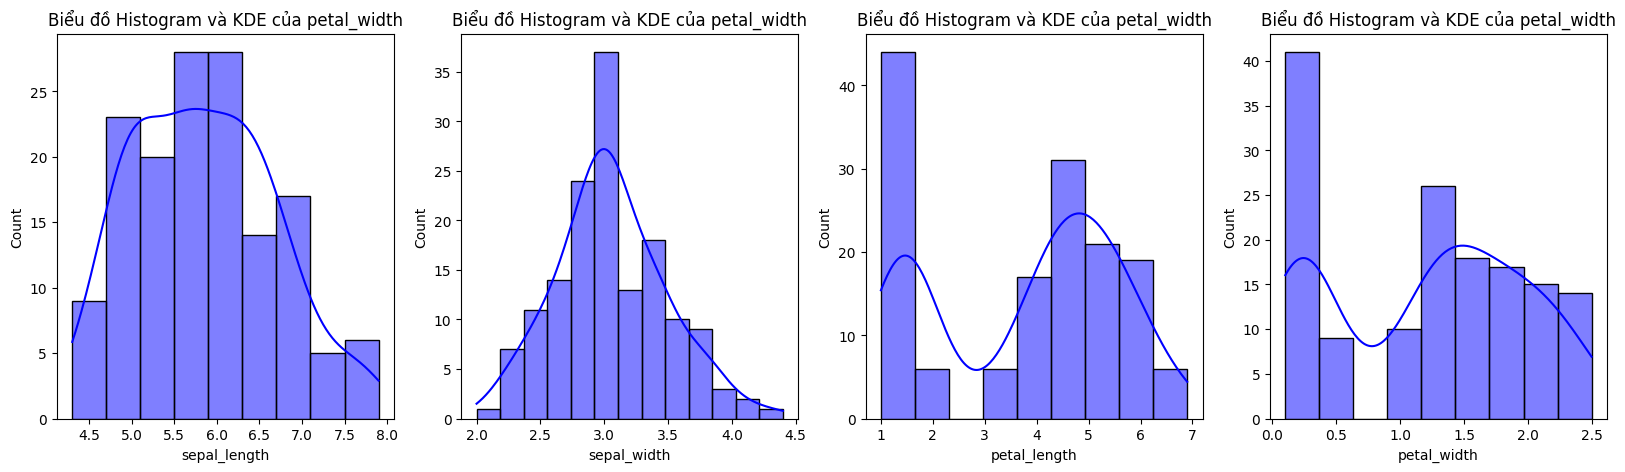

In [5]:
fig, axes = plt.subplots(nrows = 1, ncols= 4, figsize = (20,5))
for i in range(len(features)):
    sns.histplot(data=df, x = features[i], kde=True, color='Blue', ax = axes[i])
    axes[i].set_title(f'Biểu đồ Histogram và KDE của {feature}')
plt.show()

- sepal_length: có hình dạng tương đối cân đối và gần với phân phối chuẩn
- sepal_width: có hình dạng đối xứng và tương đối gần với phân phối chuẩn nhất trong 4 biểu đồ
- petal_length: biểu đồ này xuất hiện hiện tượng 2 đỉnh độc lập với nhau, điều này do sự khác biệt chỉ số giữa các loài
- petal_width: biểu đồ này cũng xuất hiện hiện tượng 2 đỉnh độc lập, chủ yếu do sự khác biệt giữa chỉ số giữa các loài

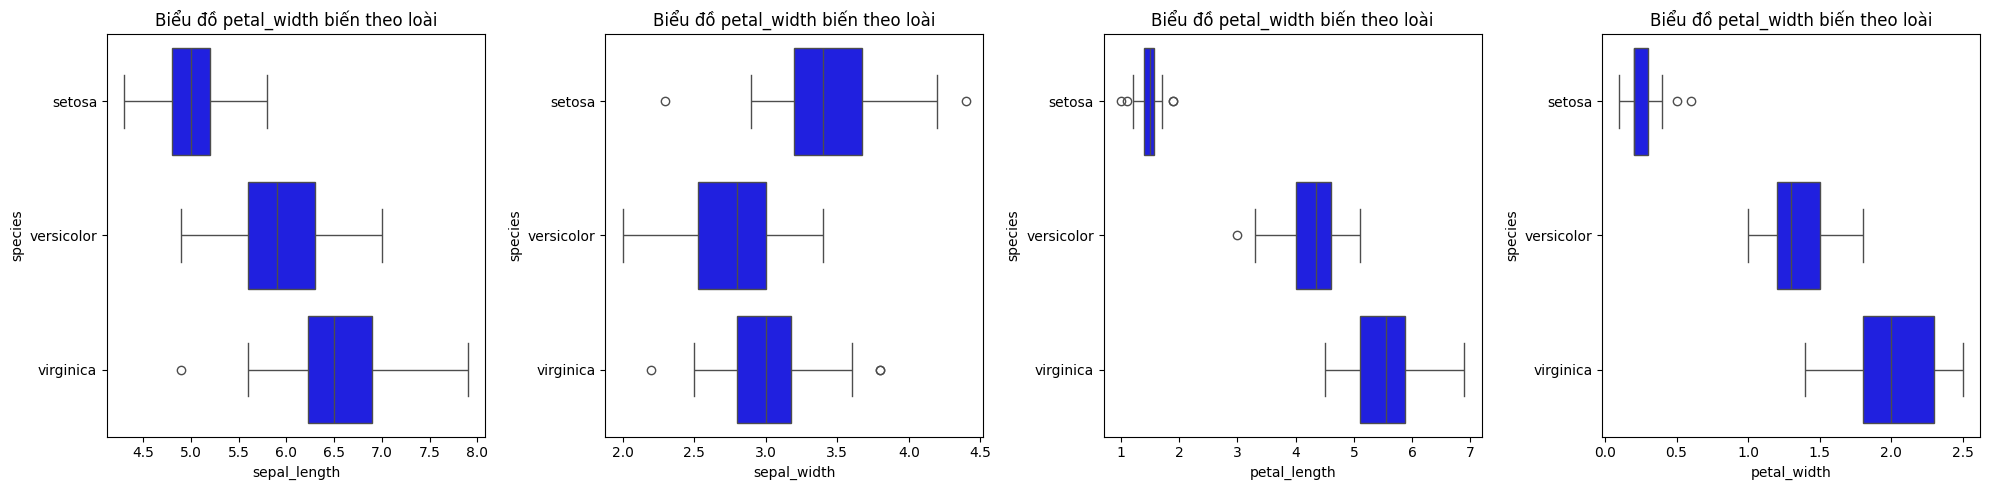

In [6]:
fig, axes = plt.subplots(nrows = 1, ncols= 4, figsize = (20,5))
for i in range(len(features)):
    sns.boxplot(data=df, x = features[i], y = 'species', color='Blue', ax = axes[i])
    axes[i].set_title(f'Biểu đồ {feature} biến theo loài')
plt.tight_layout()
plt.show()

## 2.3

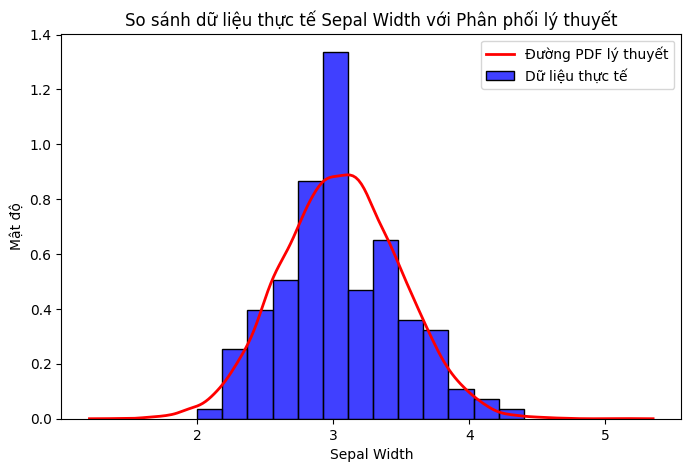

In [7]:
mu = df['sepal_width'].mean()
sigma = df['sepal_width'].std()
samples_ly_thuyet = np.random.normal(loc=mu, scale=sigma, size=10000)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df, x='sepal_width', stat='density', color='Blue', label='Dữ liệu thực tế', ax=ax)
sns.kdeplot(samples_ly_thuyet, color='Red', linewidth=2, label='Đường PDF lý thuyết', ax=ax)

ax.set_title('So sánh dữ liệu thực tế Sepal Width với Phân phối lý thuyết')
ax.set_xlabel('Sepal Width')
ax.set_ylabel('Mật độ')
ax.legend()
plt.show()

# 3 Phân tích đa biến & tương quan

## 3.1

In [8]:
df_number = df.select_dtypes(include=['number'])
ma_tran_hiep_phuong_sai = df_number.cov()
ma_tran_he_so_tuong_quan = df_number.corr()
print('Ma trận hiệp phương sai')
print(ma_tran_hiep_phuong_sai)
print('Ma trận tương quan')
print(ma_tran_he_so_tuong_quan)

Ma trận hiệp phương sai
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Ma trận tương quan
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


## 3.2

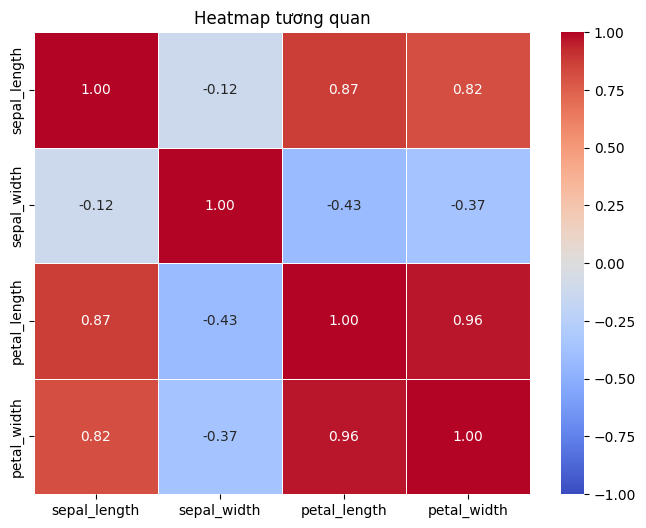

In [9]:
plt.figure(figsize = (8,6))
sns.heatmap(
    ma_tran_he_so_tuong_quan,
    annot=True,
    cmap='coolwarm',
    fmt ='.2f',
    linewidths=0.5,
    vmin = -1,
    vmax = 1
)
plt.title('Heatmap tương quan')
plt.show()

### Nhận xét:
Ta thấy có các cặp tương quan mạnh như petal_length & petal_width, petal_width & sepal_length, petal_length & petal_sepal_length. Các cặp tương quan trên có dấu hiệu đa cộng tuyến vì hệ số tương quan của 3 cặp trên đều lớn hơn 0.8 và đặc biệt petal_length & petal_width

## 3.3

<Figure size 800x600 with 0 Axes>

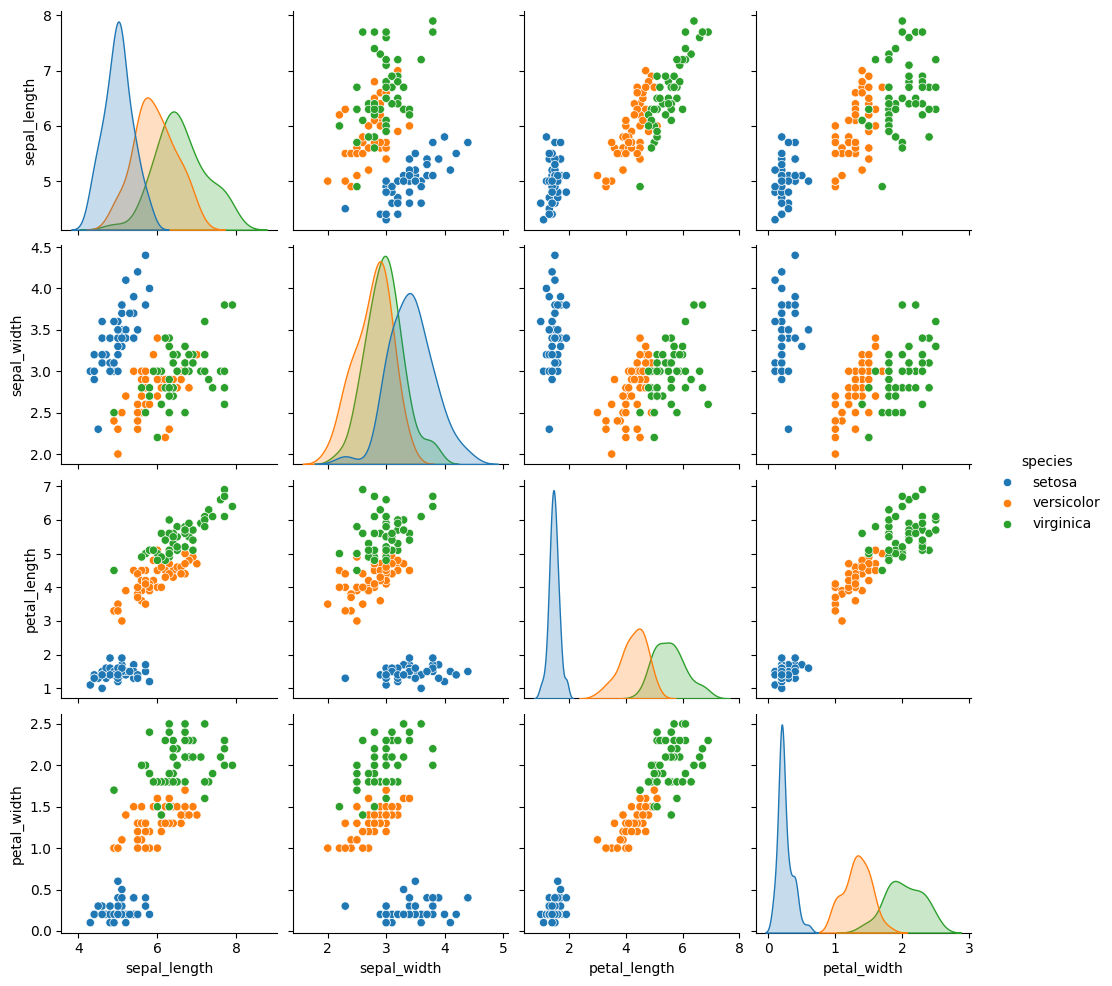

In [10]:
plt.figure(figsize = (8,6))
sns.pairplot(df, hue = 'species')
plt.show()

## Nhận xét:
- Ta thấy loài setosa(màu xanh dương) tách biệt hoàn toàn so với 2 loài còn lại. Ngược lại versicolor và virginica tương đối tương quan.
- Dễ thấy petal_length và petal_width có mối quan hệ tuyến tính khá mạnh mẽ, các biến dường như tạo thành 1 đường thẳng. Ngược lại, sepal_width và sepal_length thì các điểm phân bố khá rộng thể hiện mối quan hệ tương quan giữa chúng khá yếu.

# 4 Xác suất & Định lý Bayes

In [11]:
P_B = 0.01
tp = 0.99
fp = 0.05
P_duong_tinh = tp*P_B + fp * (1- P_B)
P_B_duong_tinh = tp*P_B / P_duong_tinh
print(P_B_duong_tinh)

0.16666666666666669


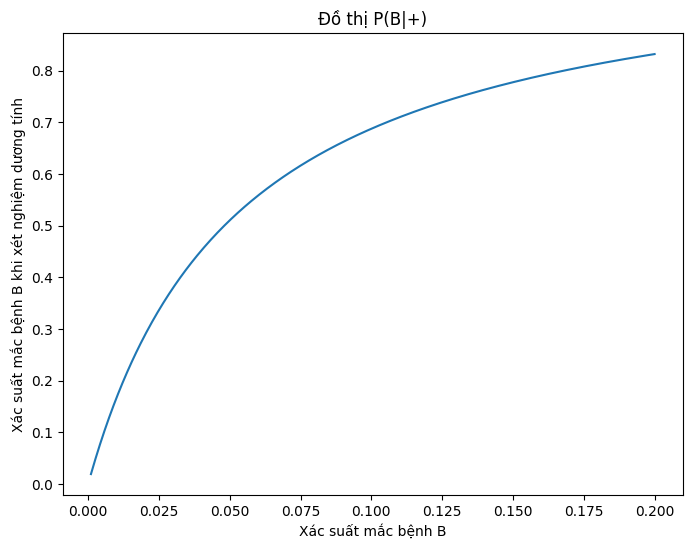

In [18]:
P_B_arange = np.linspace(0.001, 0.2, 500)
P_duong_tinh_arange = tp * P_B_arange + fp * (1-P_B_arange)
P_B_duong_tinh_arange = tp*P_B_arange/P_duong_tinh_arange
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(P_B_arange, P_B_duong_tinh_arange)
ax.set_title('Đồ thị P(B|+)')
ax.set_xlabel('Xác suất mắc bệnh B')
ax.set_ylabel('Xác suất mắc bệnh B khi xét nghiệm dương tính')
plt.show()

# Nhận xét
- Hiện tượng phản trực giác P(B) = 0.001: Dù xét nghiệm chính xác đến $99\%$, xác suất thực tế bị bệnh khi có kết quả dương tính chỉ đạt $16.67\%$. Lý do là vì bệnh quá hiếm ($1\%$), lượng người khỏe mạnh quá lớn dẫn đến số ca dương tính giả ($495$ người) hoàn toàn áp đảo số ca dương tính thật ($99$ người).
- Xu hướng biến thiên (từ $0.001 \rightarrow 0.2$): Đường cong đồ thị dốc lên rất nhanh ở giai đoạn đầu và thoải dần về sau. Điều này chứng minh: Tỷ lệ mắc bệnh trong cộng đồng càng tăng, số ca dương tính giả càng giảm dần tầm ảnh hưởng, giúp kết quả xét nghiệm dương tính càng trở nên đáng tin cậy.